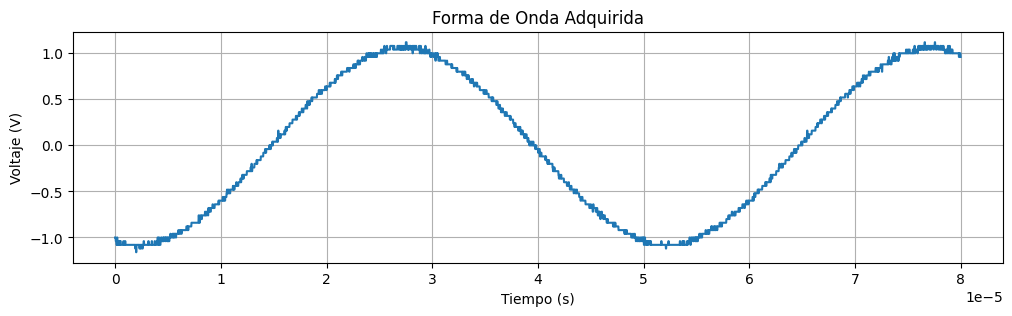

Lectura BIN: 0.0024 s, Ploteo: 0.3704 s


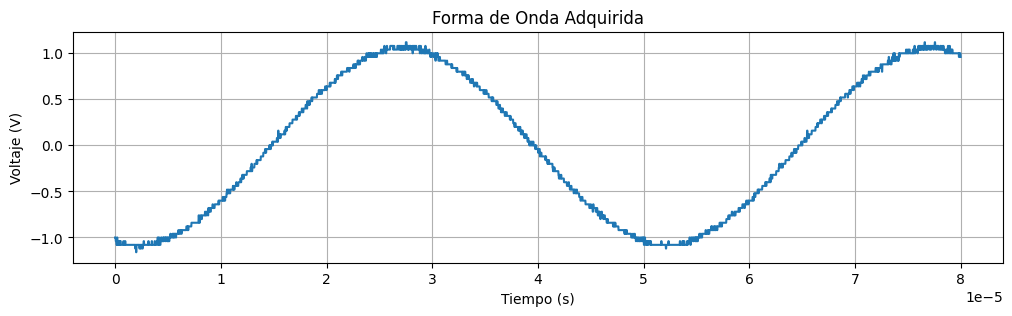

Lectura CSV: 0.0069 s, Ploteo: 0.3370 s


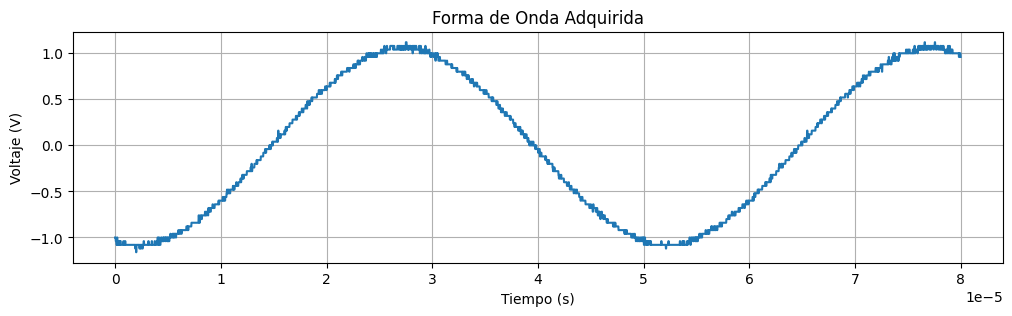

Lectura NPZ: 0.0020 s, Ploteo: 0.3345 s


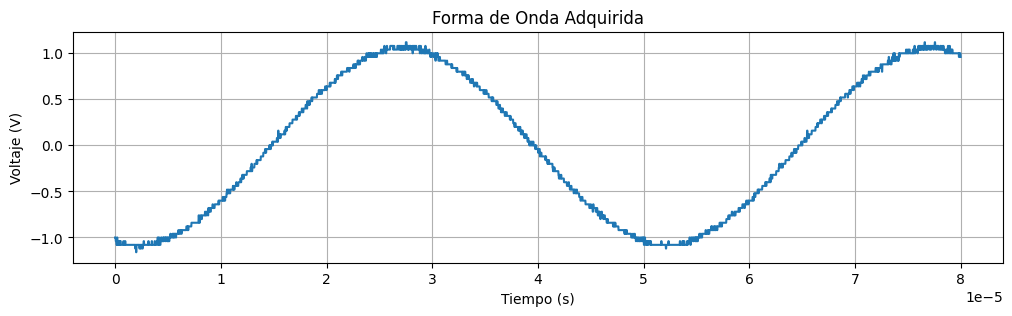

Lectura H5: 0.0043 s, Ploteo: 0.2959 s


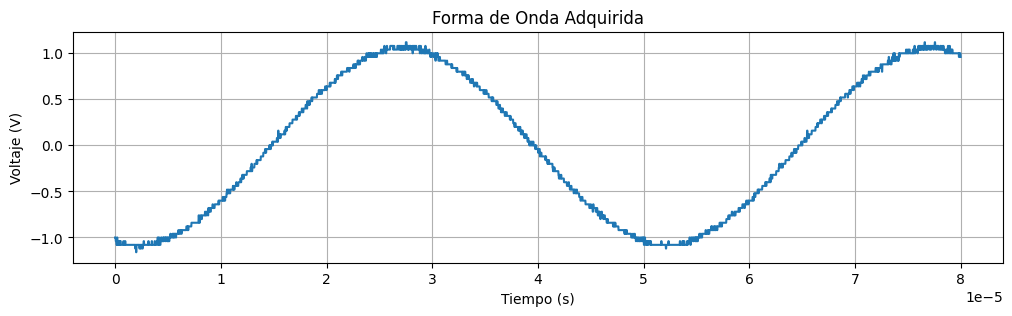

Lectura RAW: 0.0010 s, Ploteo: 0.2971 s


In [2]:
import time
from struct import unpack
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import h5py

def read_bin():
    headerlen = 6 #48008
    vdiv = 1.0
    data = np.fromfile("datos_osciloscopio.bin", dtype=np.int8)
    waveform_raw = unpack('>%sh' % (int(len(data[headerlen + 8:]) / 2)), data[headerlen + 8:])
    num = len(waveform_raw)
    waveform = [0] * num
    for i in range(num):
        waveform[i] = waveform_raw[i] * vdiv / 25
    return waveform

def read_csv():
    df = pd.read_csv("datos_osciloscopio.csv")
    return df.values.flatten()

def read_npz():
    with np.load("datos_osciloscopio.npz") as f:
        return f['arr_0']

def read_h5():
    with h5py.File("datos_osciloscopio.h5", "r") as f:
        return f["ch1"][:]

def read_raw():
    data = np.fromfile("datos_osciloscopio.raw", dtype=np.float32)
    return data

def plot_waveform(waveform, dt):
    num_points = len(waveform)
    time_axis = np.linspace(0, (num_points - 1) * dt, num_points)
    plt.figure(figsize=(12, 3))
    plt.plot(time_axis, waveform)
    plt.title("Forma de Onda Adquirida")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Voltaje (V)")
    plt.grid(True)
    plt.show()

if __name__ == '__main__':
    dt = 20e-9

    t0 = time.time()
    wave1 = read_bin()
    t1 = time.time()
    plot_waveform(wave1, dt)
    t2 = time.time()
    print(f"Lectura BIN: {t1 - t0:.4f} s, Ploteo: {t2 - t1:.4f} s")

    t0 = time.time()
    wave2 = read_csv()
    t1 = time.time()
    plot_waveform(wave2, dt)
    t2 = time.time()
    print(f"Lectura CSV: {t1 - t0:.4f} s, Ploteo: {t2 - t1:.4f} s")

    t0 = time.time()
    wave3 = read_npz()
    t1 = time.time()
    plot_waveform(wave3, dt)
    t2 = time.time()
    print(f"Lectura NPZ: {t1 - t0:.4f} s, Ploteo: {t2 - t1:.4f} s")

    t0 = time.time()
    wave4 = read_h5()
    t1 = time.time()
    plot_waveform(wave4, dt)
    t2 = time.time()
    print(f"Lectura H5: {t1 - t0:.4f} s, Ploteo: {t2 - t1:.4f} s")

    t0 = time.time()
    wave5 = read_raw()
    t1 = time.time()
    plot_waveform(wave5, dt)
    t2 = time.time()
    print(f"Lectura RAW: {t1 - t0:.4f} s, Ploteo: {t2 - t1:.4f} s")